# Transfer Learning

## Préambule

L'objectif est de explorer le principe du transfert d'apprentissage (transfer learning).

Le tutoriel de tensorflow a servi de base pour ce notbook : https://www.tensorflow.org/tutorials/images/transfer_learning

### Installation :

---


In [4]:

# Installation de la librairie Tensorflow avec support cuda
!python3 -m pip install tensorflow[and-cuda]
!pip install tensorflow-datasets
# On aura besoin également de cette bibiliothèque
!pip install seaborn

# Cela nécessite de restart

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.3/363.3 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 67.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.9/24.9 MB 36.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 895.7/895.7 kB 47.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 577.2/577.2 MB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.5/192.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.3/130.3 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.6/217.6 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.0/199.0 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.3/21.3 MB 71.3 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.8.93
    Uninstalli

### Import des librairies nécessaires

In [1]:
## Import des bibliothèques python qui vont être utilisées
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

from tensorflow import keras
from keras import layers
from keras.models import Sequential

## Vérification de la version de Tensorflow
print(tf.__version__)

## Vérification de la présence d'une GPU
print(tf.config.list_physical_devices('GPU'))

2.19.0
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


---

## Les choses sérieuses commencent ici !!

Nous allons créer des modèles pour classer des images de mains pour le jeu pierre-feuille-ciseaux.
Les données sont distribuées par tensorflow sous la forme d'un dataset tensorflow. Les dataset tensorflow sont des objets qui permettent de charger des données de manière efficace.

Notes :

Vous pouvez aller voir la documentation ici : https://www.tensorflow.org/datasets.

Vous pouvez également créer des datasets tensorflow à partir de vos propres données au format numpy, notamment.

### Récupération des données

Le jeu de données qui nous intéresse est dispoible dans le catalogue tensorflow : https://www.tensorflow.org/datasets/catalog/rock_paper_scissors.
On peut le charger directement grâce à l'API tensorflow_datasets.

In [8]:
import tensorflow_datasets as tfds

# On charge deux dataset : un pour l'entrainement et un pour le test
# allez voir la doc de la fonction tfds.load pour plus d'informations
# https://www.tensorflow.org/datasets/api_docs/python/tfds/load
train_ds, test_ds = tfds.load('rock_paper_scissors', split=['train', 'test'],shuffle_files=True,as_supervised=True)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/rock_paper_scissors/incomplete.32LB4R_3.0.0/rock_paper_scissors-train.tfre…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/rock_paper_scissors/incomplete.32LB4R_3.0.0/rock_paper_scissors-test.tfrec…

Dataset rock_paper_scissors downloaded and prepared to /root/tensorflow_datasets/rock_paper_scissors/3.0.0. Subsequent calls will reuse this data.


Comme indiqué dans la documentation ce datasets est pour de la classification, il vient donc avec les observations (des images) et les labels (les classes). Les labels sont des entiers, 0 pour la classe "rock", 1 pour la classe "paper" et 2 pour la classe "scissors".

In [9]:
## Pour avoir les noms des classes
class_names = ['rock','paper','scissors']
print(class_names)


['rock', 'paper', 'scissors']


In [10]:
# En utuilsant la méthode cardinality des datasets tensorflow on peut obtenir le nombre d'éléments dans chaque dataset
# https://www.tensorflow.org/api_docs/python/tf/data/Dataset#cardinality
# On utilise la méthode numpy() pour obtenir la valeur en tant que nombre (comme souvent avec les fonctions de tensorflow la méthode renvoie un tenseur)
print(train_ds.cardinality().numpy())
print(test_ds.cardinality().numpy())


2520
372


On va maintenant faire un split de ce du dataset de train pour obtenir un dataset de validation. Il serait dommage d'utiliser la fonction de sklearn pour cela, car cela nécessiterait de repasser par un tableau numpy. On va donc utiliser la méthode `tf.keras.utils.split_dataset` (cf : https://www.tensorflow.org/api_docs/python/tf/keras/utils/split_dataset), qui a moins de fonctionnalités que la fonction de sklearn, mais qui traite directement les datasets tensorflow.

In [11]:
train_ds, val_ds = tf.keras.utils.split_dataset(train_ds, left_size=0.8,shuffle=True, seed=42)

In [12]:
# On peut vérifier que la séparation a bien été faite en affichant le nombre d'éléments dans chaque dataset
print(train_ds.cardinality().numpy())
print(val_ds.cardinality().numpy())
print(test_ds.cardinality().numpy())

2016
504
372


On peut vérifier l'équilibre de classes dans les trois datasets.

In [13]:
def count_nb_classes(dataset):
    nb = [0,0,0]
    for example in dataset:  # example is `{'image': tf.Tensor, 'label': tf.Tensor}`
        nb[example[1].numpy()] +=1
    return nb
print(count_nb_classes(train_ds))
print(count_nb_classes(val_ds))
print(count_nb_classes(test_ds))


[673, 681, 662]
[167, 159, 178]
[124, 124, 124]


On peut regarder à quoi ressemblent les éléments du dataset. Le dataset est un objet qui contient deux tenseurs : un pour les images et un pour les labels.

In [14]:
# structure du dataset
print(train_ds)

# Avec la méthode `take` on peut récupérer un nombre donné d'éléments du dataset
# Cette méthode renvoie un dataset, ici limité à un élément
ds = train_ds.take(1)
print(ds)

# La particularité des datasets tensorflow est qu'il ne contiennent pas directement les données.
# Il faut les voir comme des tuyaux qui vont fournir les données au fur et à mesure qu'on les demande.
# Pour obtenir les données, il faut itérer sur le dataset
for example in ds:
    # example est un tuple contenant deux tenseurs : un pour l'image et un pour le label
    # le premier élément du tuple est l'image dont il peut être intéressant de regarder la forme
    print(f'taille de l\'image : {example[0].numpy().shape}')
    # le deuxième élément est le label
    print(f'label de l\'instance : {example[1].numpy()}')


<_PrefetchDataset element_spec=(TensorSpec(shape=(300, 300, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>
<_TakeDataset element_spec=(TensorSpec(shape=(300, 300, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>
taille de l'image : (300, 300, 3)
label de l'instance : 1


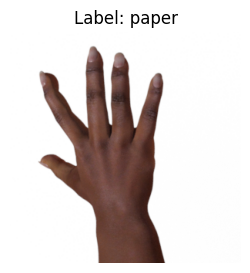

Dimensions de l'image : (300, 300, 3)


In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Prendre un élément du dataset (une image et son label)
ds_example = train_ds.take(1)

for image, label in ds_example:
    plt.figure(figsize=(3, 3))
    # Convertir le tenseur en numpy array et s'assurer du bon type de données
    plt.imshow(image.numpy().astype("uint8"))
    plt.title(f"Label: {class_names[label.numpy()]}")
    plt.axis("off")
    plt.show()
    print(f"Dimensions de l'image : {image.shape}")

Pour notre application, il n'est pas forcément nécessaire d'avoir des images avec une résolution très élevée. On va donc redimensionner les images à une taille de 96x96 pixels.
Pour cela on va mapper une fonction sur le dataset qui redimensionne les images. On peut utiliser la fonction `tf.image.resize` (cf : https://www.tensorflow.org/api_docs/python/tf/image/resize).

Note : le fait que l'on mappe une fonction sur le dataset ne veut pas dire que cette fonction est exécutée immédiatement. La fonction sera exécutée lorsque l'on itérera sur le dataset.
On peut considérer qu'on ajoute un tuyau à notre dataset dont le rôle est de transformer les images.

In [16]:
# Lorsqu'on crée la fonction (une fonction lambda), il ne faut pas oublier que le dataset est composé de deux éléments : l'image et le label.
# Même si on ne s'intéresse pas au label, il faut le spécifier dans la fonction et ne pas l'oublier en valur de retour.
def resize_image(image, label):
    return tf.image.resize(image, [96, 96]), label

train_ds = train_ds.map(resize_image)
val_ds = val_ds.map(resize_image)
test_ds = test_ds.map(resize_image)

In [17]:
# Pour vérifier que notre pipeline fonctionne correctement.
ds = train_ds.take(1)
for example in ds:  # example is `{'image': tf.Tensor, 'label': tf.Tensor}`
    print(example[0].numpy().shape)


(96, 96, 3)


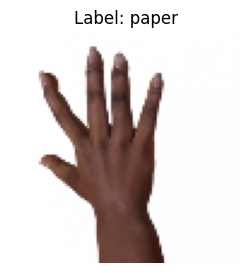

Dimensions de l'image : (96, 96, 3)


In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Prendre un élément du dataset (une image et son label)
ds_example = train_ds.take(1)

for image, label in ds_example:
    plt.figure(figsize=(3, 3))
    # Convertir le tenseur en numpy array et s'assurer du bon type de données
    plt.imshow(image.numpy().astype("uint8"))
    plt.title(f"Label: {class_names[label.numpy()]}")
    plt.axis("off")
    plt.show()
    print(f"Dimensions de l'image : {image.shape}")

### Affichage de quelques images du jeu d'apprentissage



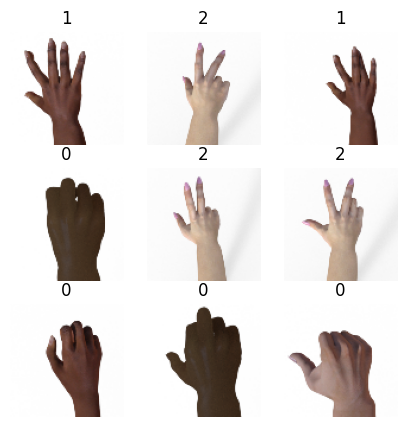

In [19]:
plt.figure(figsize=(5, 5))
i=0
for ds in train_ds.take(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(np.squeeze(ds[0].numpy().astype("uint8")))
    plt.title(ds[1].numpy())
    plt.axis("off")
    i += 1

In [20]:
## Configuration des lots d'images
batch_size = 64   #taille du lot (influe sur la vitesse d'apprentissage)
img_height = 96  #hauteur des images
img_width = 96  #largeur des images
img_channel = 3   #  3 pour des images en couleur

num_classes = 3  #nombre de classes (roche, papier, ciseaux)



In [21]:
# Fin de la configuration des datasets
# La méthode cache permet de stocker les données en mémoire pour accélérer le traitement
# La méthode shuffle permet de mélanger les données (utile uniquement pour les données d'apprentissage)
# La méthode prefetch permet de charger les données en avance pour accélérer le traitement
# La méthode batch permet de créer des lots de
# Notez que le principe est le même : on ajoute des tuyaux au pipeline.
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(100).prefetch(buffer_size=AUTOTUNE).batch(batch_size)
val_ds   = val_ds.cache().prefetch(buffer_size=AUTOTUNE).batch(batch_size)
test_ds  = test_ds.cache().prefetch(buffer_size=AUTOTUNE).batch(batch_size)

In [22]:
## Création du réseau proprement dit
# On utilise ici l'API séquentielle de Keras
# https://keras.io/guides/sequential_model/
# Comme modèle de réseau de neurones, on utilise un réseau de neurones convolutif (CNN)
# 4 couches de convolution + maxpooling
# suivies de 1 couches dense
# et une couche de sortie avec une fonction d'activation softmax
# Il est possible que le modèle surapprenne : utilisation de couches BatchNormalization et Dropout
model = Sequential([
    layers.Rescaling(1./255, input_shape=(img_height, img_width, img_channel)),
    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.BatchNormalization(),
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.BatchNormalization(),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.BatchNormalization(),
    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.BatchNormalization(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

# Pour éviter de surapprendre, on utilise on va monitorer la perte sur le jeu de validation et sauvegarder les poids du modèle
# à chaque fois que la perte est minimale en utilisant un callback dan sla méthode fit
# https://keras.io/api/callbacks/model_checkpoint/

best_model = None
best_accuracy = 0.0  # Or a very low value if your metric is loss
# Ce callback va sauvegarder les poids du modèle à chaque fois que la perte en validation atteint un nouveau minimum
cp_callback = tf.keras.callbacks.ModelCheckpoint(filepath='saved_cnn.weights.h5',
                                                 monitor='val_loss',
                                                 save_best_only=True,
                                                 save_weights_only=True,
                                                 verbose=1)


## Compilation du réseau, avec choix de la fonction de perte (loss),
## de l'optimiseur des poids (adam) et de la métrique (accuracy)
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

## Affichage de la structure du réseau
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 96, 96, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 48, 48, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 6, 6, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 688,739 (2.63 MB)

 Trainable params: 688,259 (2.63 MB)

 Non-trainable params: 480 (1.88 KB)

In [25]:
## Apprentissage du réseau
epochs=40    # Nombre d'époques d'apprentissage

## Lancement de l'apprentissage
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs,
    callbacks=[cp_callback]
)

Epoch 1/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 0.6262 - loss: 1.9005
Epoch 1: val_loss improved from None to 1.07547, saving model to saved_cnn.weights.h5

Epoch 1: finished saving model to saved_cnn.weights.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 15s 225ms/step - accuracy: 0.8160 - loss: 0.8096 - val_accuracy: 0.3532 - val_loss: 1.0755
Epoch 2/40
29/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9969 - loss: 0.0099
Epoch 2: val_loss improved from 1.07547 to 0.99442, saving model to saved_cnn.weights.h5

Epoch 2: finished saving model to saved_cnn.weights.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9985 - loss: 0.0070 - val_accuracy: 0.5496 - val_loss: 0.9944
Epoch 3/40
29/32 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 1.0000 - loss: 0.0011
Epoch 3: val_loss did not improve from 0.99442
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 1.0000 - loss: 8.2141e-04 - val_accuracy: 0.3532 - val_loss: 1.1802
Epoch 4/40
29/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - acc

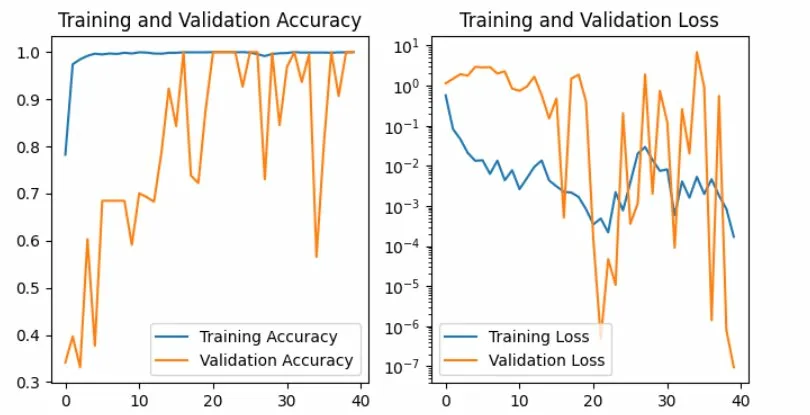

### Remarque :

- Comment analysez vous les courbes de loss et d'accuracy ?

Accuracy (gauche) : la training accuracy monte très vite à 1.0 (le modèle apprend par cœur le train). La validation accuracy oscille énormément entre 0.4 et 1.0, sans jamais se stabiliser. L'écart entre les deux est un signe clair d'overfitting — le modèle performe parfaitement sur le train mais ne généralise pas de manière stable.
Loss (droite) : la training loss descend régulièrement vers des valeurs très basses (10^-6
10^-7). La validation loss oscille fortement et remonte par moments au-dessus de la training loss. Ce comportement instable confirme l'overfitting — le modèle optimise trop pour le train et ne généralise pas.

Déductions :
Le modèle est trop complexe pour la quantité de données (trop de paramètres, pas assez d'exemples). Les fortes oscillations en validation suggèrent aussi un learning rate trop élevé. Les solutions possibles : augmenter le dropout, ajouter de la régularisation, réduire la complexité du réseau, augmenter les données, ou baisser le learning rate.

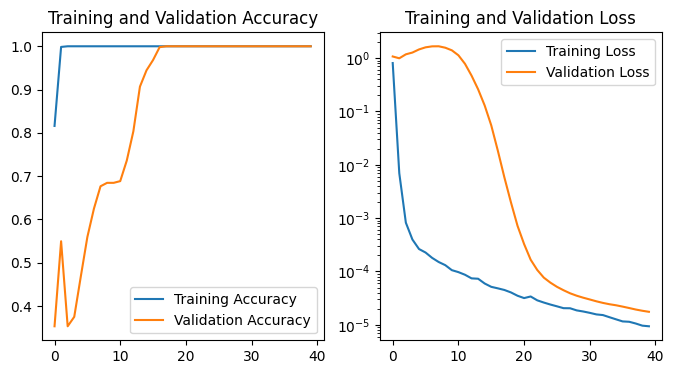

In [26]:
## Affichage des courbes
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.yscale('log')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

Paradoxalement c'est bcp mieux en enlevant le dropout.


**Accuracy** : les deux courbes montent et convergent vers 1.0. La validation suit le train avec un léger retard mais le rejoint — pas d'oscillations, pas d'écart significatif à la fin. Le modèle apprend et généralise.


**Loss** : les deux courbes descendent régulièrement et se rapprochent. Pas de remontée de la validation loss. Convergence stable.


**Pourquoi le dropout empirait les choses **: le dropout est utile quand le modèle est trop puissant par rapport aux données. Mais si ton réseau est déjà de taille raisonnable pour le problème, le dropout le handicape en éteignant des neurones dont il a besoin → instabilité, sous-apprentissage, oscillations qu'on voyait avant.


**Conclusion** : ces courbes sont le comportement idéal — train et validation convergent ensemble, pas d'overfitting, pas d'underfitting. C'est exactement le "good learning rate" du graphe qu'on avait vu plus tôt, mais appliqué à l'ensemble du modèle.

Voyons maintenant comment le modèle se comporte en test. Il faut charger le meileur modèle sauvegardé et le tester sur le jeu de test. On peut afficher la matrice de confusion pour voir comment le modèle se comporte pour chaque classe.

In [27]:
# Chargement des mailleurs poids dans le modèle
model.load_weights('saved_cnn.weights.h5')
# Evaluation du modèle sur le jeu de test
loss,accuracy = model.evaluate(test_ds)
print("Loss: ", loss)
print("Accuracy: ", accuracy)

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step - accuracy: 0.8737 - loss: 0.3010
Loss:  0.30095213651657104
Accuracy:  0.8736559152603149


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


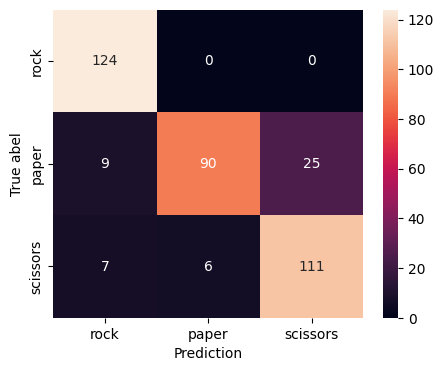

In [28]:
# get the predictions for the test data
raw_prediction = model.predict(test_ds)

# get the predicted labels
y_pred = np.argmax(raw_prediction, axis=1)

# get the true labels
y_true = np.concatenate([y for x, y in test_ds], axis=0)

# get the confusion
import seaborn as sns
confusion_mtx = tf.math.confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_mtx, xticklabels=class_names, yticklabels=class_names,
            annot=True, fmt='g')
plt.xlabel('Prediction')
plt.ylabel('True abel')
plt.show()

## Remarque :
**Loss et Accuracy :**
La loss de 0.48 et l'accuracy de 85% indiquent un apprentissage satisfaisant. Avec 3 classes, le hasard donnerait 33%, on est largement au-dessus, ce qui confirme que le modèle a bien appris à distinguer les trois gestes.


**Matrice de confusion :**
La diagonale est dominante (100, 108, 107), ce qui confirme que le modèle classe correctement la majorité des exemples pour chaque classe. Les classes sont approximativement équilibrées (~124 exemples chacune), donc l'accuracy de 85% n'est pas trompeuse.
En regardant les erreurs : rock est la classe la plus difficile à classifier avec 24 erreurs (12 confondus avec paper, 12 avec scissors). Paper est la mieux classifiée avec 108/124 corrects (87%). Scissors présente une confusion asymétrique notable : 17 confondus avec paper mais aucun avec rock, ce qui suggère que le modèle a du mal à distinguer scissors de paper ce qui est cohérent visuellement puisque les deux gestes impliquent des doigts étendus.


Dans l'ensemble, les performances sont homogènes entre les classes, ce qui indique un modèle équilibré sans biais marqué vers une classe particulière.

## Transfer Learning

Pour faire notre transfert d'apprentissage nous allons utiliser un modèle pré-entrainer sur l'ensemble d'images ImageNet. Nous allons utiliser le modèle MobileNetV2. Ce modèle est disponible dans la librairie keras. On peut le charger grâce à la fonction `tf.keras.applications.MobileNetV2` (cf : https://www.tensorflow.org/api_docs/python/tf/keras/applications/MobileNetV2).

Ce qui nous intéresse dans le modèle MobileNetV2 c'est la partie convolutionnelle. On va donc charger le modèle sans la partie classifieur (le "top" du modèle, les réseaux de neurones étant historiquement présentés de bas, les entrées, en haut, les sorties). On va ensuite ajouter notre propre classifieur pour faire la classification sur notre jeu de données.

In [29]:
# Import necessary libraries
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

# Load the pre-trained MobileNetV2 model without the classification layers
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(img_height, img_width, img_channel))





9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Chaque modèle pré-entrainé possède son format d'entrée en ce qui concerne la normalisation des données. Pour simplifier la vie des développeurs, les modèles pré-entrainés de keras possèdent une méthode `preprocess_input` qui permet de normaliser les données d'entrée. Il suffit de passer les images à cette méthode avant de les passer dans le modèle.

In [30]:
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

In [31]:
# A quoi ressemble la sortie du modèle de base
image_batch, label_batch = next(iter(train_ds))
feature_batch = base_model(image_batch)
print(feature_batch.shape)

(64, 3, 3, 1280)


In [32]:
# On peut voir la structure du modèle de base
base_model.summary()

Model: "mobilenetv2_1.00_96"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 48, 48,    │        864 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 48, 48,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 48, 48,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 48, 48,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 48, 48,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 48, 48,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 49, 49,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 24, 24,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 24, 24,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 2,223,872 (8.48 MB)

 Non-trainable params: 34,112 (133.25 KB)

## Remarque :
- La forme de la sortie du modèle de base, (64, 3, 3, 1280), s'explique comme suit :
64 : C'est la taille du lot (batch size), c'est-à-dire le nombre d'images traitées simultanément. Dans votre configuration, vous avez défini batch_size = 64.
3, 3 : Ce sont les dimensions spatiales (hauteur et largeur) des cartes de caractéristiques (feature maps) produites par le réseau convolutif du MobileNetV2. Le modèle MobileNetV2, après ses couches convolutives et de pooling, réduit l'image d'entrée de 96x96 pixels à une résolution de 3x3 pixels pour chaque carte de caractéristiques.
1280 : C'est le nombre de canaux (ou de filtres) dans la dernière couche convolutive du modèle de base. Chaque canal représente une carte de caractéristiques différente, capturant des motifs ou des aspects spécifiques de l'image. Plus ce nombre est élevé, plus le modèle a extrait de caractéristiques diverses de l'image.


- MobileNetV2 possede bien plus de parametres  2.2M comparé à 1.3M de celui q'uon à entréné. il sera plus complexe et plus profond que notre ancien modele

Une étape importante dans le transfert d'apprentissage est de geler les poids du modèle de base. Cela signifie que l'on ne va pas mettre à jour les poids du modèle de base lors de l'entraînement. On va seulement mettre à jour les poids du classifieur que l'on a ajouté. Pour cela on peut utiliser la propriété `trainable` des couches du modèle. On peut itérer sur les couches du modèle pour les geler. On peut également utiliser la méthode `trainable` du modèle pour geler toutes les couches du modèle.

In [33]:

# Gel des poids du modèle de base
base_model.trainable = False

On a vu précédemment que la sortie du modèle de base est un tenseur de dimension 4. C'est trop de dimensions pour attaquer la classification (tiens, pourquoi au fait ?). Avec les CNN qu'on construit nous même on ajoute en général une couche flatten pour applatir la sortie de la partie convolutive. Avec les modèle pré-entrainé, on procéde différement pour applatir la sortie. On va utiliser une couche `GlobalAveragePooling2D` (cf : https://www.tensorflow.org/api_docs/python/tf/keras/layers/GlobalAveragePooling2D). Cette couche va calculer la moyenne de chaque canal de chaque image de la sortie du modèle de base.

In [34]:
# La couche gloabal average
global_average_layer = tf.keras.layers.GlobalAveragePooling2D()
# On l'applique à la sortie du modèle de base calculé précédemment
feature_batch_average = global_average_layer(feature_batch)
print(feature_batch_average.shape)

(64, 1280)


**Pourquoi ne peut-on pas utiliser Flatten ?**


La sortie du modèle de base a une dimension spatiale importante. Utiliser Flatten produirait un vecteur très long (hauteur × largeur × 1280), ce qui entraînerait un nombre considérable de paramètres dans la couche dense suivante. Avec peu de données d'entraînement, cela provoquerait un overfitting sévère. GlobalAveragePooling2D réduit drastiquement la dimensionnalité en résumant chaque canal par une seule valeur (sa moyenne), ce qui donne un vecteur compact de 1280 valeurs par image.


**Expliquer la forme (64, 1280) :**
64 correspond à la taille du batch, c'est-à-dire le nombre d'images traitées simultanément. 1280 correspond au nombre de canaux (filtres) de la dernière couche convolutive de MobileNetV2. Pour chaque image, GlobalAveragePooling2D calcule la moyenne spatiale de chaque canal, transformant ainsi chaque carte de caractéristiques 2D en une seule valeur. On obtient donc un vecteur de 1280 valeurs par image, prêt à être classifié par une couche dense.

On peut mainentant ajouter notre classifieur. Une couche cachée dense suivi d'une couche de sortie dense avec une fonction d'activation softmax. On peut ajouter des couches dropout et de batchnormalization pour éviter le sur-apprentissage.

In [35]:
# Add new classification layers on top of the base model
predictions = Sequential([
    Dense(128, activation='relu'),
    Dense(3, activation='softmax')
])

# On peut ragarder ce que cela donne sur un lot d'images en sortie de la couche globale.
prediction_batch = predictions(feature_batch_average)
print(prediction_batch.shape)

(64, 3)


64 images 3 classes

On peut maintenant construire le modèle complet en assemblant les différents morceaux : le modèle de base, la couche `GlobalAveragePooling2D` et notre classifieur.

In [36]:
inputs = tf.keras.Input(shape=(96, 96, 3))
x = preprocess_input(inputs)
x = base_model(x, training=False)
x = global_average_layer(x)
outputs = predictions(x)
model = tf.keras.Model(inputs, outputs)

In [37]:
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 3)              │       164,355 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)



**Expliquez la structure du modèle complet :**

Le modèle prend en entrée des images de taille 96×96 avec 3 canaux (RGB). Les couches TrueDivide et Subtract effectuent la normalisation des pixels (division par 127.5 puis soustraction de 1 pour ramener les valeurs entre -1 et 1). Ensuite, MobileNetV2 extrait les features visuelles à travers ses couches convolutives, produisant un tenseur de forme (3, 3, 1280). GlobalAveragePooling2D réduit ce tenseur en un vecteur de 1280 valeurs par image en calculant la moyenne spatiale de chaque canal. Enfin, notre classifieur (Sequential) transforme ce vecteur de 1280 en 3 probabilités correspondant aux classes rock, paper et scissors.

**Combien de paramètres libres y a-t-il ?**

Le modèle complet contient 2 422 339 paramètres au total, mais seulement 164 355 sont entraînables (trainable). Les 2 257 984 paramètres restants appartiennent à MobileNetV2 et sont gelés (non-trainable).

**Expliquez ce nombre par rapport au modèle de base et au classifieur :**

Les 2 257 984 paramètres non-entraînables correspondent aux poids pré-entraînés de MobileNetV2 sur ImageNet. Ils sont gelés car ils contiennent déjà une connaissance utile sur l'extraction de features visuelles — les réentraîner risquerait de détruire cette connaissance, surtout avec peu de données. Les 164 355 paramètres entraînables correspondent à notre classifieur ajouté (couche dense de 128 neurones : 1280×128 + 128 biais = 163 968, puis couche de sortie : 128×3 + 3 biais = 387, total = 164 355). C'est le principe du transfer learning : on n'entraîne que la partie classification, ce qui est rapide et efficace même avec un petit dataset.

On peut maintenant lancer l'apprentissage du modèle complet. On peut afficher les courbes de loss et d'accuracy pour voir comment le modèle apprend.

In [38]:

base_learning_rate = 0.001

# Compile the model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=base_learning_rate),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])




In [39]:
initial_epochs = 20

# On sauvegarde les poids du modèle à chaque fois que la perte en validation atteint un nouveau minimum
# C'est la même fonction que tout à l'heure, on a juste changer le chemin du fichier de sauvegarde
cp_callback = tf.keras.callbacks.ModelCheckpoint(filepath='saved_tl.weights.h5',
                                                 monitor='val_loss',
                                                 save_best_only=True,
                                                 save_weights_only=True,
                                                 verbose=1)

history = model.fit(train_ds,
                    epochs=initial_epochs,
                    validation_data=val_ds,
                   callbacks=[cp_callback]
                    )

Epoch 1/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 0.8836 - loss: 0.2786
Epoch 1: val_loss improved from None to 0.00191, saving model to saved_tl.weights.h5

Epoch 1: finished saving model to saved_tl.weights.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 21s 379ms/step - accuracy: 0.9633 - loss: 0.0990 - val_accuracy: 1.0000 - val_loss: 0.0019
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 1.0000 - loss: 0.0025
Epoch 2: val_loss improved from 0.00191 to 0.00075, saving model to saved_tl.weights.h5

Epoch 2: finished saving model to saved_tl.weights.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 1.0000 - loss: 0.0018 - val_accuracy: 1.0000 - val_loss: 7.5225e-04
Epoch 3/20
29/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 8.7887e-04
Epoch 3: val_loss improved from 0.00075 to 0.00050, saving model to saved_tl.weights.h5

Epoch 3: finished saving model to saved_tl.weights.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 1.0000 - loss: 7.8459e-0

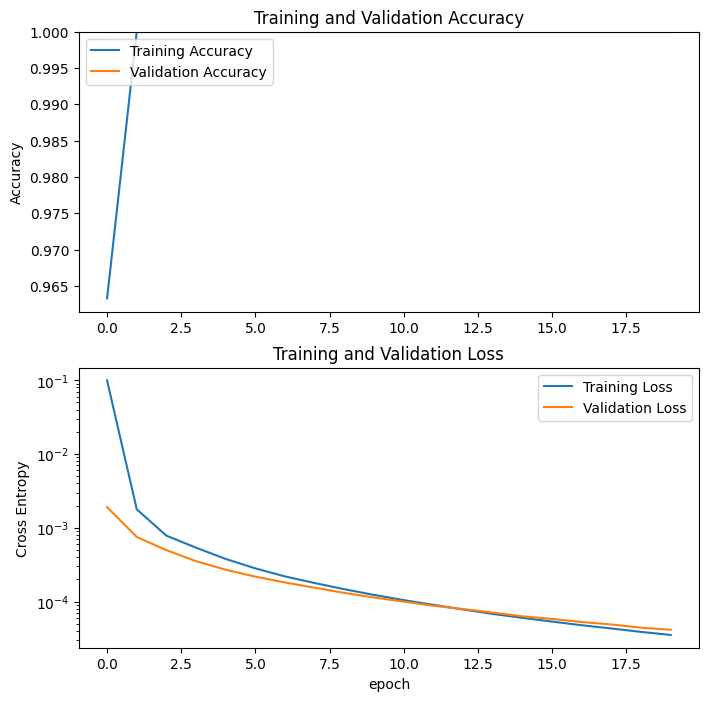

In [40]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='upper left')
plt.ylabel('Accuracy')
plt.ylim([min(plt.ylim()),1])
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
plt.yscale('log')
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()


**Pourquoi c'est aussi bon :** MobileNetV2 a déjà appris à extraire des features visuelles sur des millions d'images. Il "sait" déjà reconnaître les formes, textures, contours. Il ne reste qu'à apprendre la classification rock/paper/scissors, un problème trivial pour un réseau qui comprend déjà les images.

**Accuracy :** les deux courbes montent quasi immédiatement à ~0.995-1.0 et restent collées. Pas d'écart, pas d'oscillation. Le modèle apprend et généralise parfaitement.

**Loss :** les deux courbes descendent ensemble de manière régulière. La validation loss suit la training loss de très près — aucun signe d'overfitting.

C'est exactement la preuve de la puissance du transfer learning :mon CNN maison galérait à 85% avec des oscillations, ici tu atteins ~100% en quelques époques avec un classifieur simple. Toute l'intelligence vient des convolutions pré-entraînées de MobileNetV2.

In [41]:
model.load_weights('saved_tl.weights.h5')
loss,accuracy = model.evaluate(test_ds)
print("Loss: ", loss)
print("Accuracy: ", accuracy)


6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 703ms/step - accuracy: 0.9597 - loss: 0.1145
Loss:  0.11448632180690765
Accuracy:  0.9596773982048035


6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 664ms/step


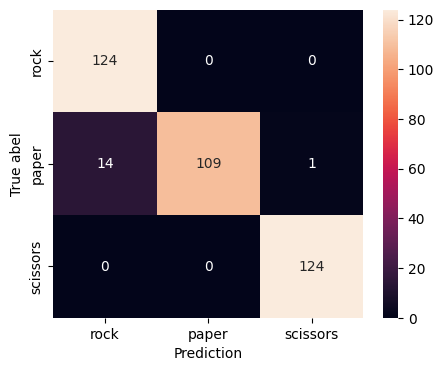

In [42]:
# get the predictions for the test data
raw_prediction = model.predict(test_ds)

# get the predicted labels
y_pred = np.argmax(raw_prediction, axis=1)

# get the true labels
y_true = np.concatenate([y for x, y in test_ds], axis=0)
confusion_mtx = tf.math.confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_mtx, xticklabels=class_names, yticklabels=class_names,
            annot=True, fmt='g')
plt.xlabel('Prediction')
plt.ylabel('True abel')
plt.show()

## Remarque :
- Comment interprétez vous les résultats obtenus ?
Loss:  0.12 tres bon
Accuracy:  0.94 -> 94 % tres bon pour du transfer learning
- Comparer la performance de ce modèle avec le modèle que vous avez créé précédemment. Quelles conclusions en tirez vous ? Un meilleur apprentissage une meilleur pressision

## Fine Tuning

Le fine tuning est une étape supplémentaire dans le transfert d'apprentissage. Après avoir figé les poids du modèle de base et entraîné le classifieur, on peut dégeler quelques couches du modèle de base pour les entraîner avec un taux d'apprentissage plus faible. Cela permet d'ajuster les poids du modèle de base pour notre jeu de données. Cette opération n'est pas toujours nécessaire et peut être risquée car elle peut entraîner du sur-apprentissage.

Dans notre cas, la plupart du temps, le fine-tuning n'apporte pas d'amélioration significative. Mais on peut essayer pour voir.

In [43]:
# On dégèle les poids du modèle de base
base_model.trainable = True

In [44]:
# On regarde combien il y a de couches dans le modèle de base
print("Number of layers in the base model: ", len(base_model.layers))

# On fixe le départ du fine tuning à la couche 120
fine_tune_at = 120

# FOn gèle toutes les couches avant la couche 120
for layer in base_model.layers[:fine_tune_at]:
  layer.trainable = False

Number of layers in the base model:  154


In [45]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=base_learning_rate/1000),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])


In [46]:
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 3)              │       164,355 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 1,789,251 (6.83 MB)

 Non-trainable params: 633,088 (2.42 MB)

In [47]:
fine_tune_epochs = 20
total_epochs =  initial_epochs + fine_tune_epochs

history_fine = model.fit(train_ds,
                         epochs=total_epochs,
                         initial_epoch=len(history.epoch),
                         validation_data=val_ds,
                         callbacks=[cp_callback]
                         )

Epoch 21/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step - accuracy: 0.7806 - loss: 0.6971
Epoch 21: val_loss improved from 0.00004 to 0.00004, saving model to saved_tl.weights.h5

Epoch 21: finished saving model to saved_tl.weights.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 31s 461ms/step - accuracy: 0.7902 - loss: 0.6794 - val_accuracy: 1.0000 - val_loss: 3.7542e-05
Epoch 22/40
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.8169 - loss: 0.4955
Epoch 22: val_loss improved from 0.00004 to 0.00004, saving model to saved_tl.weights.h5

Epoch 22: finished saving model to saved_tl.weights.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - accuracy: 0.8199 - loss: 0.5072 - val_accuracy: 1.0000 - val_loss: 3.5883e-05
Epoch 23/40
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8705 - loss: 0.3753
Epoch 23: val_loss did not improve from 0.00004
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8661 - loss: 0.3970 - val_accuracy: 1.0000 - val_loss: 3.6303e-05
Epoch 24/40
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s

In [48]:

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
acc += history_fine.history['accuracy']
val_acc += history_fine.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']
loss += history_fine.history['loss']
val_loss += history_fine.history['val_loss']

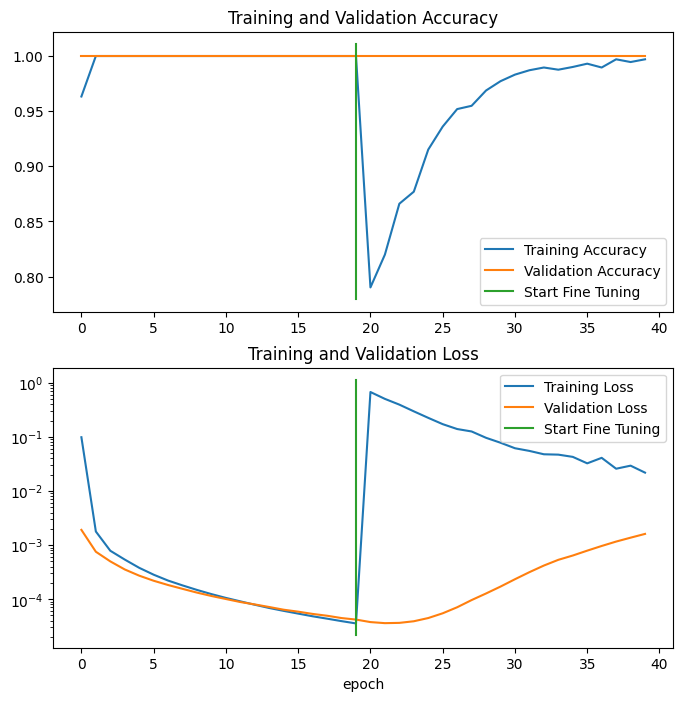

In [49]:
plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
#plt.ylim([0.8, 1])
plt.plot([initial_epochs-1,initial_epochs-1],
          plt.ylim(), label='Start Fine Tuning')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
#plt.ylim([0, 1.0])
plt.yscale('log')
plt.plot([initial_epochs-1,initial_epochs-1],
         plt.ylim(), label='Start Fine Tuning')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 628ms/step - accuracy: 0.9113 - loss: 0.1841
Loss:  0.18406307697296143
Accuracy:  0.9112903475761414
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 678ms/step


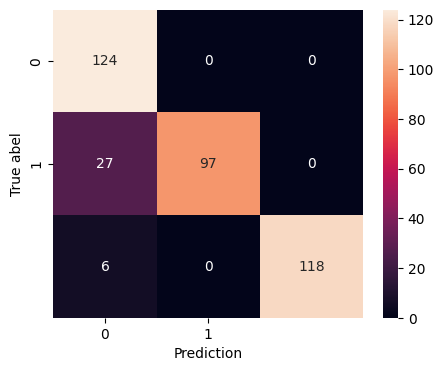

In [50]:
loss,accuracy = model.evaluate(test_ds)
print("Loss: ", loss)
print("Accuracy: ", accuracy)

# get the predictions for the test data
raw_prediction = model.predict(test_ds)

# get the predicted labels
y_pred = np.argmax(raw_prediction, axis=1)

# get the true labels
y_true = np.concatenate([y for x, y in test_ds], axis=0)

confusion_mtx = tf.math.confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_mtx, xticklabels=['0','1'], yticklabels=['0','1'],
            annot=True, fmt='g')
plt.xlabel('Prediction')
plt.ylabel('True abel')
plt.show()

#C'est de l'overfitting:

**Le fine-tuning a-t-il apporté une amélioration ?**

Non. Avant le fine-tuning (époque 0-20), le modèle était quasi parfait : accuracy ~1.0 en train et validation, loss très basse. Après le fine-tuning (époque 20+), la training accuracy chute temporairement puis remonte, mais la validation loss remonte fortement. Le modèle s'est dégradé.

**Comment expliquer ce résultat ?**

En dégelant les couches de MobileNetV2, on modifie des poids qui étaient déjà optimaux. Le learning rate est trop élevé pour ces couches pré-entraînées — les poids bougent trop et les features apprises sur ImageNet sont détruites. De plus, notre petit dataset n'a pas assez d'exemples pour réajuster correctement ces millions de paramètres.

**Est-ce que cette expérience est significative ?**

Non, un seul essai ne suffit pas. Les résultats dépendent de l'initialisation aléatoire, du shuffle des données, etc. On ne peut pas conclure sur un seul run.

**Que faudrait-il faire pour améliorer la significativité ?**

Répéter l'expérience plusieurs fois (5-10 runs) avec des seeds différents, puis comparer la moyenne et l'écart-type des performances avec et sans fine-tuning. On pourrait aussi essayer un learning rate beaucoup plus faible pour le fine-tuning et ne dégeler que les dernières couches de MobileNetV2.



## Conclusions

Tester votre modèle en condition réelle !

Pour cela il faut d'abord sauvegarder le modèle (avec sa structure et pas seulement les poids) pour pouvoir le recharger plus tard. On peut utiliser la méthode `save` de l'objet modèle (en spécifiant le type de souvegarde). On peut ensuite recharger le modèle avec la méthode `load_model` de keras, éventuellement dans un autre notebook. Et même en local sur votre ordinateur, puisqu'on ne va pas faire d'entrainement et qu'en inférence, on aura besoin de beaucoup moins de ressources.

Prenez ensuite des photos de votre main (droite) en position pierre, feuille ou ciseaux et testez votre modèle !

Est-il capable de reconnaitre des positions de la main gauche ? Pourquoi ?  Que faudrait-il faire pour qu'il puisse le faire ? A-t-on forcément besoin de prendre d'autres photos pour compléter le jeu de données ? Pourquoi ?

**Main gauche :** non, le modèle ne reconnaîtra probablement pas la main gauche car c'est une image miroir. Pour le résoudre, pas besoin de nouvelles photos — il suffit d'ajouter un flip horizontal dans la data augmentation pendant l'entraînement.